# The Ocean's Longest Diving Animals

How long can air-breathing animals hold their breath while diving? Which animals can stay submerged for the longest time?

The file `longest-diving-animals.csv` contains the recorded durations, in minutes, of the longest dives ever recorded in the scientific literature for different species of marine mammals. 

In [ ]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'longest-diving-animals.csv'.

# from google.colab import files
# uploaded = files.upload()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('longest-diving-animals.csv')
df.head()

,animal,category,duration
0,Emperor Penguin,penguins,32.2
1,King Penguin,penguins,9.2
2,Rockhopper Penguin,penguins,3.2
3,Macaroni Penguin,penguins,6.3
4,Royal Penguin,penguins,7.5


### Project Ideas

- Create horizontal bar plots to show the longest diving animals, either for each category or within a category.

- Follow the Pro Tips.

- Convert dive durations from minutes to hours for easier understanding - 2.5 hours is clearer than 150 minutes.

- Add a reference bar to help readers build intuition about the durations. 

Side Note: The longest time a person has held their breath underwater is 24 minutes 37 seconds. This was done at the surface of a pool, not while freediving, so it might not directly comparable.


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   animal    108 non-null    object 
 1   category  108 non-null    object 
 2   duration  108 non-null    float64
dtypes: float64(1), object(2)
memory usage: 2.7+ KB


In [2]:
df['duration_hrs'] = df['duration']/60
df.head()

,animal,category,duration,duration_hrs
0,Emperor Penguin,penguins,32.2,0.536667
1,King Penguin,penguins,9.2,0.153333
2,Rockhopper Penguin,penguins,3.2,0.053333
3,Macaroni Penguin,penguins,6.3,0.105000
4,Royal Penguin,penguins,7.5,0.125000


In [3]:
# Create reference entry for human record (24.617 minutes / 60 ≈ 0.41 hours)
human_ref = pd.DataFrame({
    'animal': ['Human Record (Pool)'],
    'category': ['reference'],
    'duration': [24.617],
    'duration_hrs': [24.617 / 60]
})

# Append reference data
df_plot = pd.concat([df, human_ref], ignore_index=True)

In [4]:
df_plot

,animal,category,duration,duration_hrs
0,Emperor Penguin,penguins,32.200,0.536667
1,King Penguin,penguins,9.200,0.153333
2,Rockhopper Penguin,penguins,3.200,0.053333
3,Macaroni Penguin,penguins,6.300,0.105000
4,Royal Penguin,penguins,7.500,0.125000
...,...,...,...,...
104,Humpback Whale,baleen whales,24.000,0.400000
105,Atlantic Walrus,walruses,49.000,0.816667
106,Dungong,other marine mammals,10.000,0.166667
107,Florida Manatee,other marine mammals,24.000,0.400000


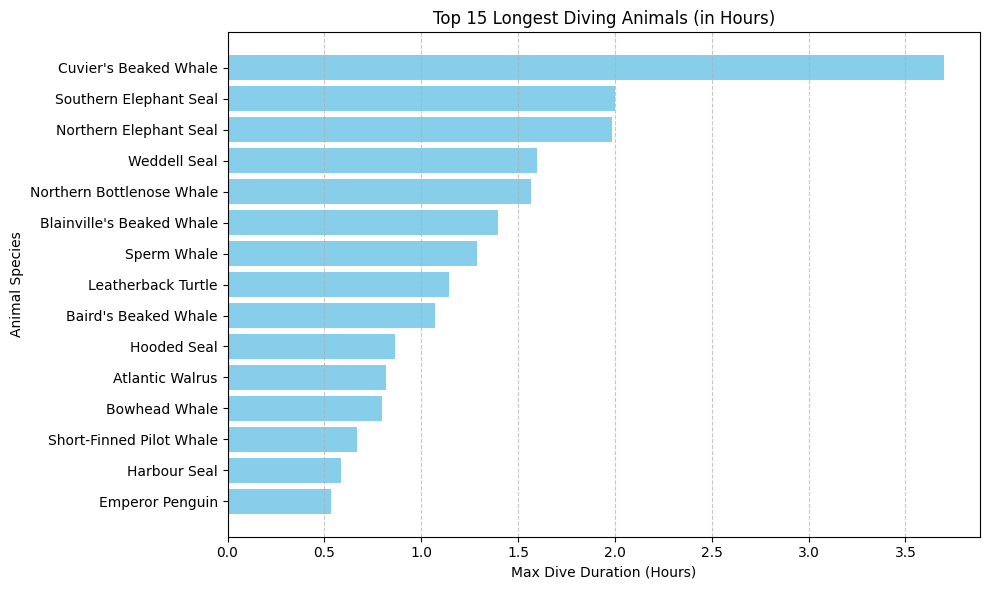

In [5]:
# Get top 15 longest divers
top_15 = df_plot.sort_values(by='duration_hrs', ascending=True).tail(15)

# Plot horizontal bars
plt.figure(figsize=(10, 6))
bars = plt.barh(top_15['animal'], top_15['duration_hrs'], color='skyblue')

# Highlight the human reference bar in a different color
for bar, animal in zip(bars, top_15['animal']):
    if 'Human' in animal:
        bar.set_color('orange')

plt.xlabel('Max Dive Duration (Hours)')
plt.ylabel('Animal Species')
plt.title('Top 15 Longest Diving Animals (in Hours)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

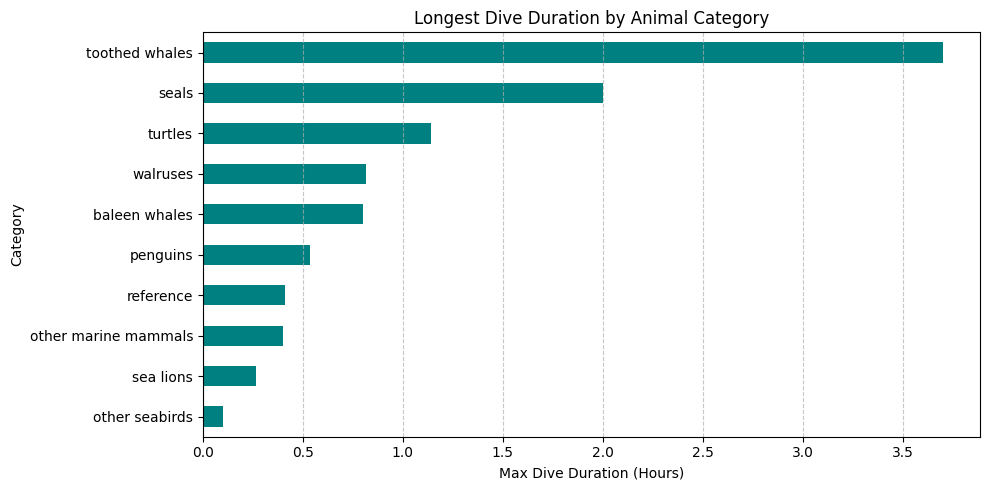

In [6]:
# Group by category and find the maximum dive duration
category_max = df_plot.groupby('category')['duration_hrs'].max().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
category_max.plot(kind='barh', color='teal')
plt.xlabel('Max Dive Duration (Hours)')
plt.ylabel('Category')
plt.title('Longest Dive Duration by Animal Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()